### Youtube Comment Analysis

- we are influencer mgmt company
- we are new company & we are not able to reach max. influencers
- we want to increase reach and onboard more influencers
- what if we can provide a free software which will develop trust and then we can push in our deals/projects
- what tool?
    - we can provide a comment analysis tool
    - which will enable them to understand the gist of all the comments - broader picture
    - what thier fan base is expecting from them and what they can deliver to attract more subs
    - it will act as an instant feedback mechanism
    - we can make a YT plugin

### Solution

1. **Sentiment Analysis of the comments**
    - real time sentiment classification
    - sentiment distribution visualization - summarized form
    - detailed sentiment insights -- filter all comments by positive, negative & nuetral
    - trend tracking (date wise positive & negative comments)

2. **Summary of comments**
    - automated comment summarization using NLP
    - highlight key themes (topic modelling)

3. **Additional comment analysis features**
    - word cloud visualization
    - average comment length
    - spam & troll detection
    - export data function

### Challenges

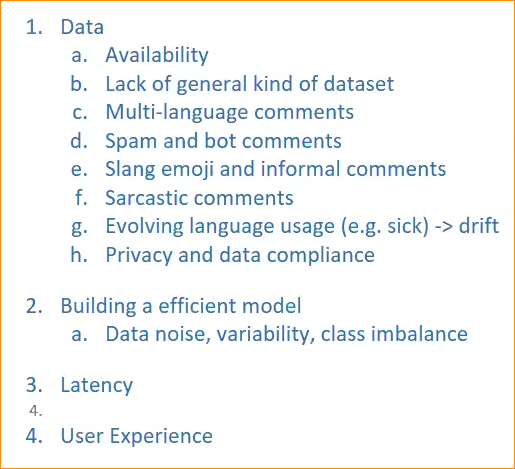

### Workflow

1. Data Gathering
2. Data Preprocessing
3. EDA
4. Model building, Hyperparameter tuning, Evaluation -- Keep tracking experiments
5. Build DVC pipeline
6. Register model
7. Build API
8. Develop chrome plugin
9. Setup CI/CD pipeline
10. Testing
11. Build docker image
12. Deploy on AWS

### Technologies

1. version control & collabration
    - git
    - github
2. data mgmt and data versioning
    - dvc
    - aws s3
3. machine learning & experiment tracking
    - python
    - ml libraries
    - NLP libraries: BERT
    - MLFlow & model registry
    - Optuna
4. CICD
    - github actions
5. Cloud services and infra
    - AWS ASG & EC2
    - Codedeploy
    - cloud watch
    - iam
6. Programming Language
    - python, js, html & css
7. Data Processing
    - pandas & numpy
8. Frontend development tools
    - chrome extension APIs
    - browser development tools
    - VS Code   
9. Testing frameworks
    - pytest, unittest, jest
10. Project management and communication
    - Jira, Airtable
11. Communication tool
    - Slack, MS Teams
12. Devops & mlops tools
    - docker
13. Security & compliance
    - SSL/TLS certs
14. Monitoring and Logging
    - AWS cloudwatch tools
    - Prometheus
    - Grafana
15. API
    - Flask
    - FastAPI
    - Postman
16. Code quality and documentation
    - pylint
    - sphinx
17. Additional tools and libraries
    - matplotlib
    - seaborn
    - d3.js
18. Data seriolization formats
    - json                 

### Experiments

- **We will perform multiple experiments as follows:**
    1. Baseline Experiment to find minimum accuracy, pain points and a direction to move
    2. Experiment to find best feature engineering technique
    3. Experiment to find best max features value
    4. Experiment to find best imbalance data handling technique
    5. Experiment to Find best algorithm with basic hyper parameter tuning
    6. Experiment to find best hyper parameters of best algorithm

### WORKFLOW
- Create DVC Pipeline of Best Experiment

- After we have best techniques, algorithms and thier hyper parameters, we can create a DVC pipeline of that setting like below:
    
    0. Setup DVC
        - dvc init
        - dvc remote add -d myremote C:\Users\iampr\AppData\Local\Temp (or S3 path)

    1. Data Ingestion
        - fetch data from url
        - basic cleaning: dropna, drop duplicates, drop empty strings, split train-test, store in data/raw folder

    2. Data Preprocessing
        - fetch from data/raw
        - apply basic preprocessing: lower, remove urls, stopwords removal, punctuations removal, lammatization
        - store into data/interim
    
    3. Model Building (performing feature engineering & model building in the same stage, ideally it should be done seperatly)
        - fetch from data/interim
        - apply tfidf: trigram with max features 10k
        - 
        - train lightgbm model using same setting as in best experiments
        - save model & tfidf vectorizer into pkl

    4. Model evaluation
        - fetch test data from data/interim
        - apply tfidf using vectorizer
        - load model & do predictions
        - print classification report

    5. create 2 files dvc.yaml & params.yaml

    6. Replace dvc remote local storage to cloud storage(AWS S3)
    
    7. Connect MLFlow to DVC pipeline workflow so that everytime dvc pipeline runs, It will log all data on MLFlow. 

    8. Register model to mlflow model registry so that in future we can fetch to make predictions in productions. For that we need:
        - run id of the experiment where we created a model and want to register that model -- whic is under "experiments_info.json"
        - model path which is in the mlflow artifcats
        - **when we register model, Its stage will be None so we will promote the model to "Staging" in register model stage**
        - In staging model, we will perform testing and promote model to Production.
        - As many times we will run the pipeline, It will register the model.

    9. We can fetch the latest model in production from model registry in FlaskAPI and make predictions

    10. Chrome Plugin will have 2 parts:
        - Frontend - ChromPlugin (HTML,CSS, JS), Whenever we will open this plugin on any YT video, It will extract all comments and send it to **backend**
        - Backend - Its a flask api which will fetch latest model from model registry, make predictions and send it back to frontend which will be displayed on frontend
        

    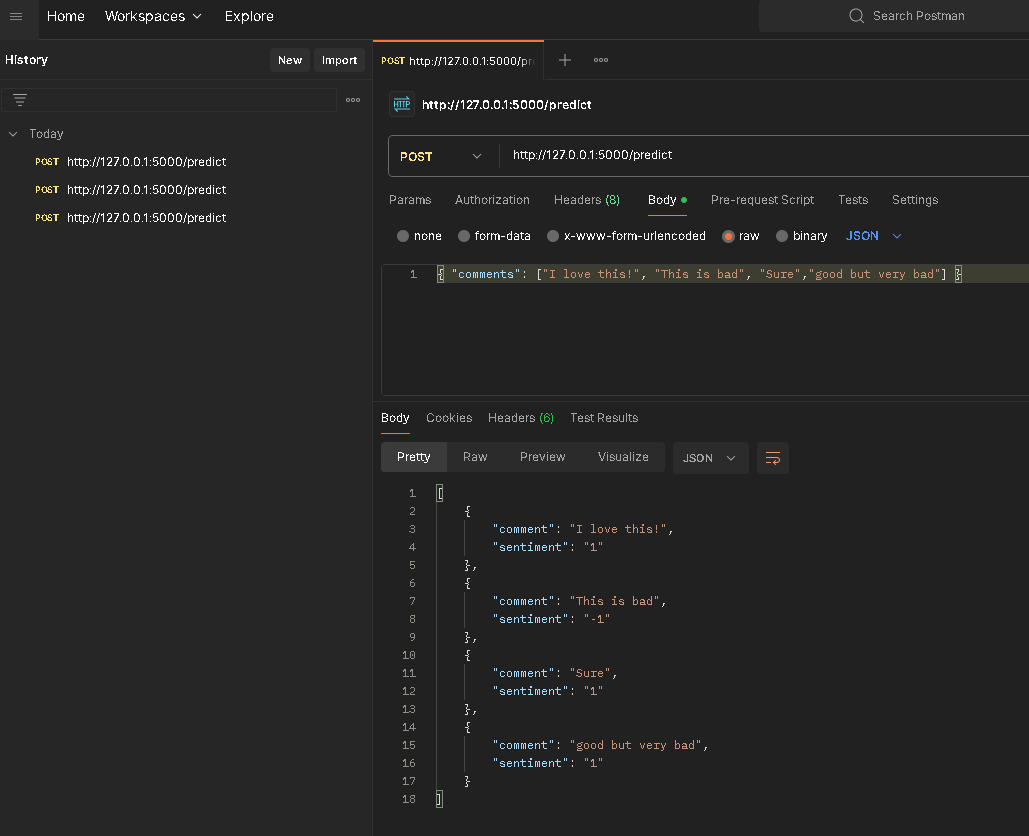




#### Chrome Plugin

1. Create a new folder & open in VS Code
2. We need 2 files:
    - manifest file
    - html file
3. Test chrome plugin - we will send a random comment to backend and it will return sentiment of that comment
4. Add all features in Flask API like sentiment values, pie chart, wordcloud, trend etc
5. This is how it looks

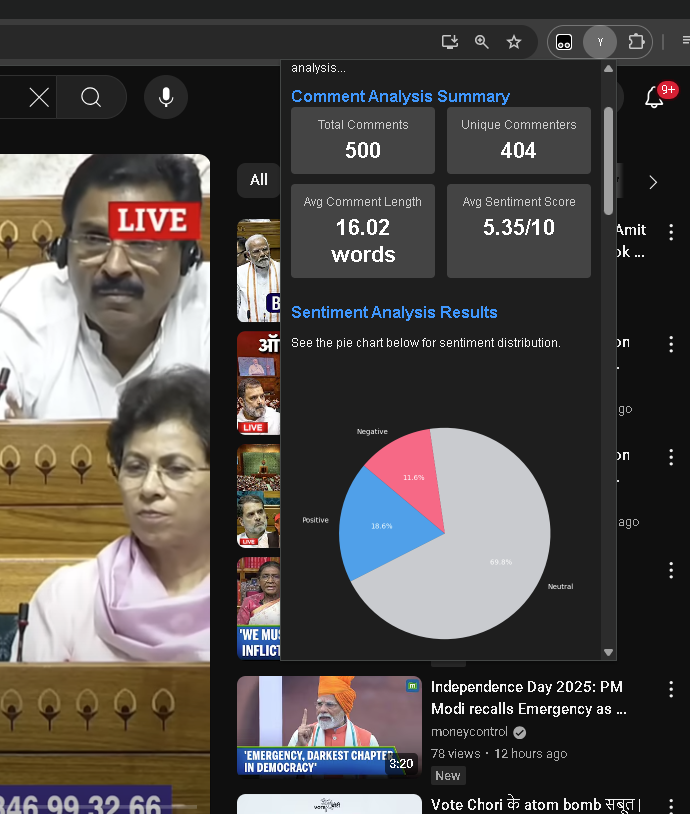

#### Deployment

1. Frontend: Chrome Plugin - Deploy it on Chrome Webstore OR Publish on Github for anyone to download and use with instructions
2. Backend: FlaskAPI which is fetching model from mlflow model registry for predictions.
    - We will add CI/CD pipeline
    - Dockerize flask app
    - Deploy on AWS + CodeDeploy

#### CI (Continous Integration)

1. Run DVC pipeline on push -- This will generate a model and that model will be pushed to ML Flow model registry in Staging.
    - Also, we need to run "dvc push" on github runner to update changes on S3 and github.
    - This may create a infinite loop since we want cicd to trigger on push but since here we are pushing using github bot, it will keep on pushing and cicd keep on triggering and fall into loop trap, So we have added a if test in cicd
    - also we need to provide "Workflow permissions" in github setting > action > workflow

2. Model Testing (Before pushing it to Production)
    - Model loading - whether loading or not
    - Model signature - shape mismatch -- add model signature
    - Performance Testing (Accuracy Threshold) previous model comparison
    - Promote model after test passed

3. Flask API Testing

4. Dockerize Flask App
    - Create ECR on AWS
    - Create requirements only for flask app
        - pip install pipreqs
        - run "pipreqs . --force" from the same directory which in our case is flask_app
    - Create Dockerfile
    - Use Gunicorn (Production Server for Flask + Build docker images into stages to reduce the size of the image)
    - Test Docker image locally before pushing to ecr
    - docker build -t yt-chrome-plugin . && docker run -e DAGSHUB_PAT=7bed6b5be2021b1a4eaae221787bcb048ab2bcfd -p 5000:5000 yt-chrome-plugin
    - docker system prune -a --volumes -f
    - Dockerize flask api
    - Test the app using Postman
    - if testing works perfectly then create ECR repo on AWS
    - push docker image to ECR using CICD


5. Deploy Docker Image on Ec2 using CI/CD
    0. Create Iam role: 
    1. Create Launch Template: "MyTemplate"
        - enter user data to install code deploy agent
    2. Create ASG "my-asg" using above launch template
    3. Check if codedeploy agent are running on ASG EC2 instances or not: sudo service codedeploy-agent status
    4. Create new CodeDeploy application
    5. Create Deployment group inside above application
        - create IAM role for codedeploy access
    6. We need "appspec.yml", "install_dependencies", "start_docker" files
        - create these files in project folder & push to github
        - zip into files on github & store on s3
        - provide the address of s3 in deployment
        - all this to be done using CI/CD pipeline






1. Generate requirements.txt - Install requirements on github runners before running dvc pipeline
2. Add AWS_REGION, AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY under Settings → Secrets → Actions
3. Add CI_CD.yaml inside .github/workflows
4. Push the update to trigger cicd & run dvc pipeline on github actions
    - sometimes dvc fails when pulling data from dvc -- run "dvc push" again
    - empty git push to trigger dvc pipeline -- git commit --allow-empty -m "Trigger CI pipeline" && git push

In [2]:
##